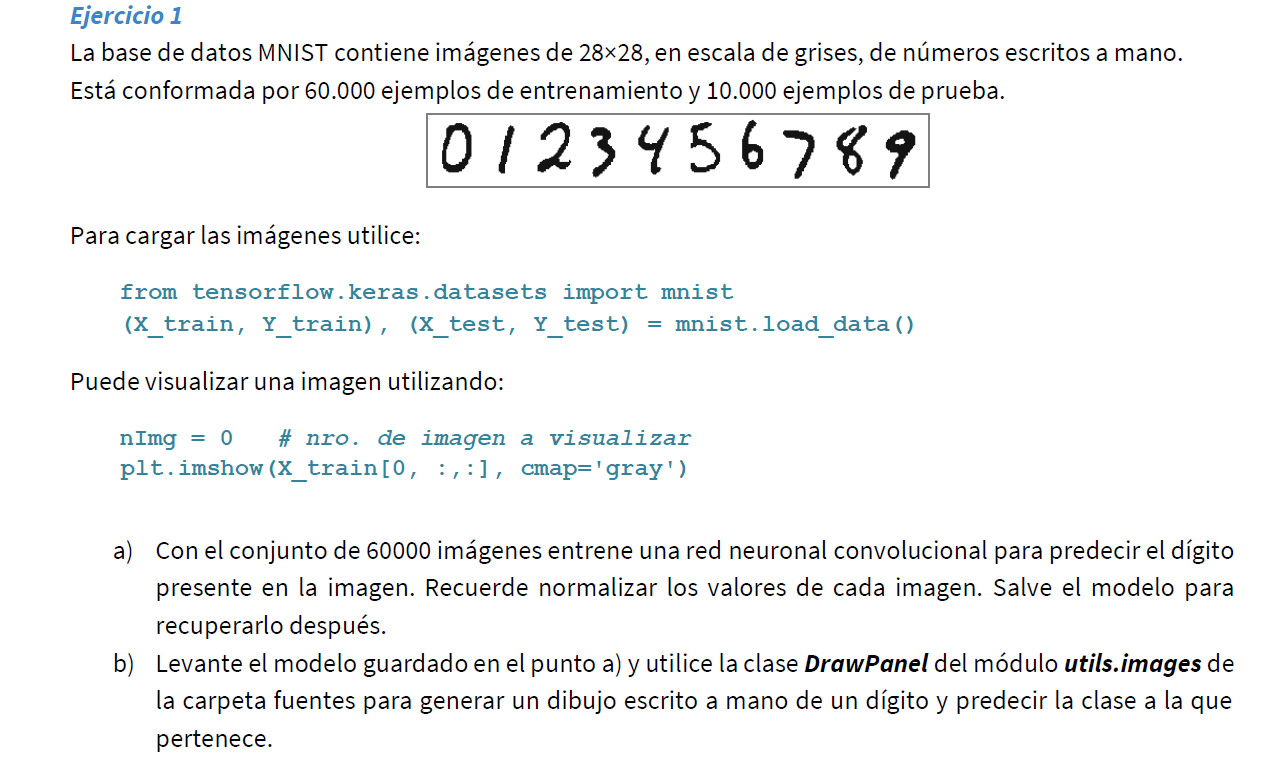

# importo imagenes


In [9]:
from tensorflow.keras.datasets import mnist
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

# visualizacion la imagen


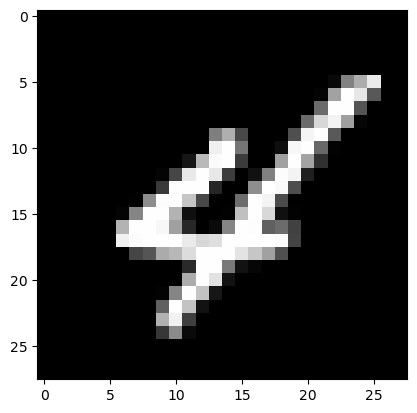

In [10]:
import matplotlib.pyplot as plt

# Ejemplo de visualización
plt.imshow(X_train[127, :, :], cmap='grey')  # Muestra la primera imagen en escala de grises
plt.show()


In [12]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [13]:
#Normalizo los valores de las imagenes entre 0 y 1
X_train=X_train.astype("float32")/255
X_test=X_test.astype("float32")/255

In [14]:
#Eedimensiono las imagenes para tener un solo canal
X_train=X_train.reshape(X_train.shape[0],28,28,1)
X_test=X_test.reshape(X_test.shape[0],28,28,1)

In [15]:
#Aplico one hot encoding a las etiquetas
Y_train=to_categorical(Y_train,10)
Y_test=to_categorical(Y_test,10)

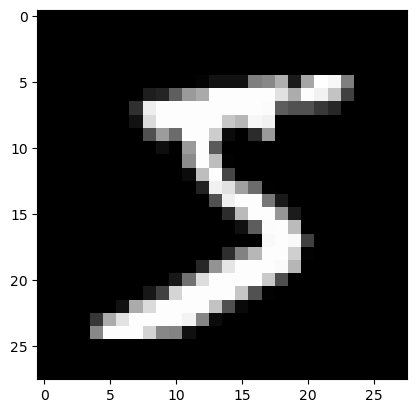

In [16]:
# Visualizar una imagen de entrenamiento
nImg = 0  # Número de la imagen a visualizar
plt.imshow(X_train[nImg, :, :, 0], cmap='gray')
plt.show()

# Creo la red convolucionar

In [50]:
TARGET_CNT= len(Y_train[0])
#Creo la red convolucionar
model=Sequential()
model.add(Conv2D(128, kernel_size=(3,3), strides=(1,1), activation='relu',  input_shape=(28, 28, 1)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, kernel_size=(3,3), strides=(1,1), activation='relu' ))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(100, activation='leaky_relu'))
model.add(Dense(TARGET_CNT, activation='softmax'))


In [51]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │       160,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,182 (922.59 KB)

 Trainable params: 236,182 (922.59 KB)

 Non-trainable params: 0 (0.00 B)

# Entreno al modelo

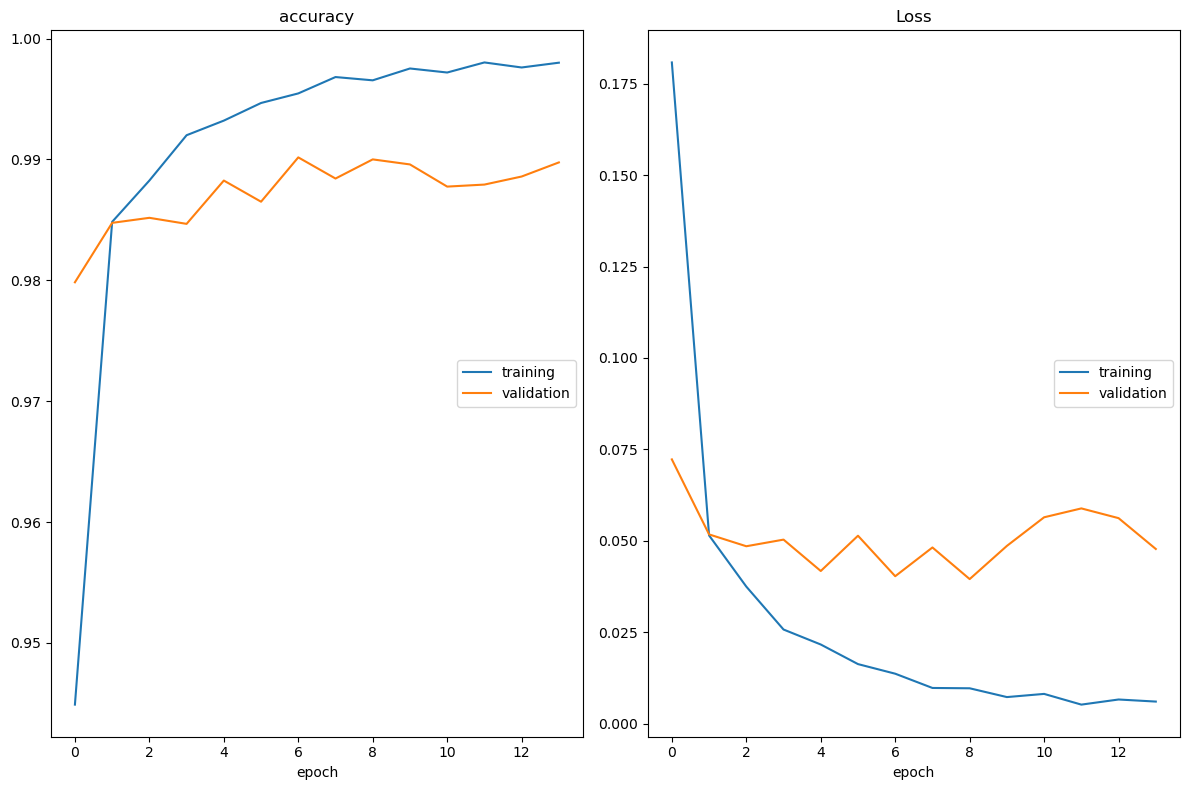

accuracy
	training         	 (min:    0.945, max:    0.998, cur:    0.998)
	validation       	 (min:    0.980, max:    0.990, cur:    0.990)
Loss
	training         	 (min:    0.005, max:    0.181, cur:    0.006)
	validation       	 (min:    0.040, max:    0.072, cur:    0.048)
480/480 ━━━━━━━━━━━━━━━━━━━━ 30s 62ms/step - accuracy: 0.9989 - loss: 0.0038 - val_accuracy: 0.9898 - val_loss: 0.0478
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9879 - loss: 0.0390
Precisión en el conjunto de prueba: 99.06%


In [52]:
#Entreno al modelo
LOTES  = 100
EPOCAS = 25
PACIENCIA = 5 
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=PACIENCIA, restore_best_weights=True)
from livelossplot import PlotLossesKeras

# %% Entrenamiento del modelo usando datos de entrenamiento y validacion
H = model.fit(x=X_train, y=Y_train, batch_size=LOTES,
              epochs=EPOCAS, validation_split=0.2, callbacks=[PlotLossesKeras(), early_stop], verbose=1)
#Evaluo el modelo
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f"Precisión en el conjunto de prueba: {test_accuracy * 100:.2f}%")

# Guardo el modelo

In [53]:

# Guardar el modelo en la ruta específica
model.save(r"C:\\Users\\Usuario\\Documents\\fran\\Facultad\\Segundo cuatri 2024\\Deep-Learning\\05-Redes convolucionares y modelos pre-entrenados\\Practica\\trainin_model.keras")

# Salvo el modelo

In [54]:

from tensorflow.keras.models import load_model
model=load_model(r"C:\\Users\\Usuario\\Documents\\fran\\Facultad\\Segundo cuatri 2024\\Deep-Learning\\05-Redes convolucionares y modelos pre-entrenados\\Practica\\trainin_model.keras")

In [55]:
import pygame
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

# Inicializar pygame
pygame.init()

# Dimensiones del panel de dibujo (ajustado para 200x200 píxeles)
WIDTH, HEIGHT = 200, 200
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)

# Crear la pantalla
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Dibuja un dígito")

# Llenar la pantalla de blanco
screen.fill(WHITE)

# Variable para salir del bucle
drawing = False

def draw_circle(screen, x, y):
    pygame.draw.circle(screen, BLACK, (x, y), 10)

# Bucle principal de pygame
running = True
while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        if event.type == pygame.MOUSEBUTTONDOWN:
            drawing = True
        if event.type == pygame.MOUSEBUTTONUP:
            drawing = False
        if event.type == pygame.MOUSEMOTION and drawing:
            x, y = event.pos
            draw_circle(screen, x, y)

    pygame.display.update()

# Guardar la imagen dibujada
pygame.image.save(screen, "digit.png")
print("Imagen guardada como 'digit.png'")

# Cerrar pygame
pygame.quit()

# Cargar la imagen y redimensionarla a 28x28 para el modelo
try:
    img = Image.open("digit.png").convert('L')  # Convertir a escala de grises
    img = img.resize((28, 28))  # Redimensionar a 28x28
    img_array = np.array(img)
    print("Imagen cargada y redimensionada a 28x28")

    # Invertir los colores y normalizar la imagen
    img_array = 255 - img_array
    img_array = img_array / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)
except Exception as e:
    print(f"Error al procesar la imagen: {e}")

# Cargar el modelo
try:
    model = load_model(r"C:\\Users\\Usuario\\Documents\\fran\\Facultad\\Segundo cuatri 2024\\Deep-Learning\\05-Redes convolucionares y modelos pre-entrenados\\Practica\\trainin_model.keras")
    print("Modelo cargado correctamente")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")

# Hacer la predicción
try:
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)
    print(f"El dígito predicho es: {predicted_class[0]}")
except Exception as e:
    print(f"Error en la predicción: {e}")


Imagen guardada como 'digit.png'
Imagen cargada y redimensionada a 28x28
Modelo cargado correctamente
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
El dígito predicho es: 7
